# **PART-III Building a CNN**

In [1]:
from google.colab import files
uploaded = files.upload()  # Upload ZIP file

Saving cnn_dataset.zip to cnn_dataset.zip


In [2]:
!unzip -q /content/cnn_dataset.zip -d /content/dataset

In [3]:
!pip install torch torchvision

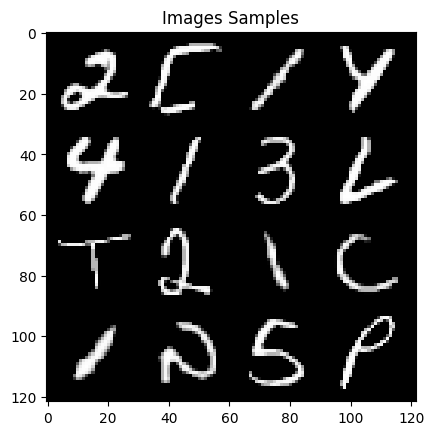

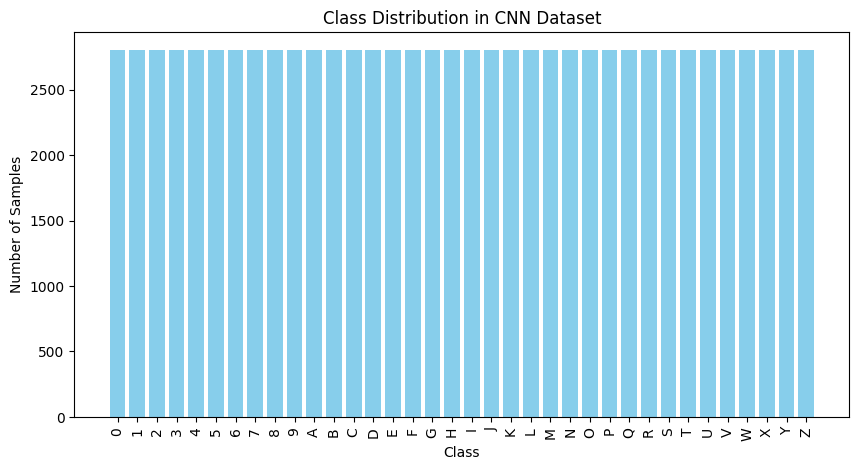

In [6]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch.optim as optim
import time
# Define the transformations
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Loading the dataset
dataset = datasets.ImageFolder(root='/content/dataset/cnn_dataset', transform=transform)
training_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
testing_size = len(dataset) - training_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [training_size, val_size, testing_size])

# Creating DataLoaders
train_data_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_data_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_data_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Visualizing some samples
def visual_samples(loader):
    batch = next(iter(loader))
    images, labels = batch
    grid_img = torchvision.utils.make_grid(images[:16], nrow=4)
    plt.imshow(grid_img.permute(1, 2, 0))
    plt.title("Images Samples")
    plt.show()

visual_samples(train_data_loader)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Histogram of Class Distribution
def class_distribution_plot(dataset):
    class_counts = [0] * len(dataset.classes)
    for _, label in dataset.samples:
        class_counts[label] += 1

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(dataset.classes)), class_counts, color='skyblue')
    plt.xlabel('Class')
    plt.ylabel('Number of Samples')
    plt.title('Class Distribution in CNN Dataset')
    plt.xticks(range(len(dataset.classes)), dataset.classes, rotation=90)
    plt.show()
class_distribution_plot(dataset)



In [8]:
!pip install torchinfo

In [9]:
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

class Basic_CNN_MODL(nn.Module):
    def __init__(self, num_classes=36):
        super(Basic_CNN_MODL, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = Basic_CNN_MODL()
print(summary(model, input_size=(64, 3, 28, 28))) #Prints model summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Using GPU
model.to(device)


Layer (type:depth-idx)                   Output Shape              Param #
Basic_CNN_MODL                           [64, 36]                  --
├─Conv2d: 1-1                            [64, 32, 28, 28]          896
├─MaxPool2d: 1-2                         [64, 32, 14, 14]          --
├─Conv2d: 1-3                            [64, 64, 14, 14]          18,496
├─MaxPool2d: 1-4                         [64, 64, 7, 7]            --
├─Conv2d: 1-5                            [64, 128, 7, 7]           73,856
├─MaxPool2d: 1-6                         [64, 128, 3, 3]           --
├─Linear: 1-7                            [64, 256]                 295,168
├─Dropout: 1-8                           [64, 256]                 --
├─Linear: 1-9                            [64, 36]                  9,252
Total params: 397,668
Trainable params: 397,668
Non-trainable params: 0
Total mult-adds (M): 528.07
Input size (MB): 0.60
Forward/backward pass size (MB): 22.63
Params size (MB): 1.59
Estimated Total Size (MB

Basic_CNN_MODL(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=36, bias=True)
)

In [10]:
# Hyperparameters
numb_epochs = 10
learning_rate = 0.001

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop for the model
training_losses, validation_losses = [], []

for epoch in range(numb_epochs):
    start_time = time.time()
    model.train()
    running_loss = 0.0
    for images, labels in train_data_loader:
        images, labels = images.to(device), labels.to(device)  # Moving data to GPU
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    average_train_loss = running_loss / len(train_data_loader)
    training_losses.append(average_train_loss)
    end_time = time.time()
    print(f"Epoch [{epoch+1}/{numb_epochs}], Train Loss: {average_train_loss:.4f}, Time: {end_time - start_time:.2f}s")

# Saving the model weights
torch.save(model.state_dict(), 'sreedivy_meerahus_assignment2_part3.pt')


Epoch [1/10], Train Loss: 0.5751, Time: 60.25s
Epoch [2/10], Train Loss: 0.2990, Time: 41.71s
Epoch [3/10], Train Loss: 0.2582, Time: 40.06s
Epoch [4/10], Train Loss: 0.2349, Time: 46.41s
Epoch [5/10], Train Loss: 0.2158, Time: 39.75s
Epoch [6/10], Train Loss: 0.2026, Time: 39.05s
Epoch [7/10], Train Loss: 0.1900, Time: 38.16s
Epoch [8/10], Train Loss: 0.1800, Time: 37.56s
Epoch [9/10], Train Loss: 0.1695, Time: 38.49s
Epoch [10/10], Train Loss: 0.1652, Time: 38.06s


In [11]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Applying Improvement Methods to reduce loss

# Early stopping
early_stopping_patience = 3
best_los = float('inf')
epochs_noimprove = 0
numb_epochs=10
# Learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
train_accuracies = []
val_accuracies = []
training_losses = []
validation_losses = []

# Training loop after improvements
for epoch in range(numb_epochs):
    start_time = time.time()
    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0  # For the accuracy
    for images, labels in train_data_loader:
        images, labels = images.to(device), labels.to(device) # Moving devide to GPU
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        # Calculates accuracy
        _, predicted = outputs.max(1)
        correct_train += predicted.eq(labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = running_loss / len(train_data_loader)
    training_losses.append(avg_train_loss)
    train_acc = correct_train / total_train
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    running_val_loss = 0.0
    correct_val, total_val = 0, 0  # For validation accuracy
    with torch.no_grad():
        for images, labels in val_data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            # Calculates validation accuracy
            _, predicted = outputs.max(1)
            correct_val += predicted.eq(labels).sum().item()
            total_val += labels.size(0)

    avg_val_loss = running_val_loss / len(val_data_loader)
    validation_losses.append(avg_val_loss)
    val_acc = correct_val / total_val
    val_accuracies.append(val_acc)

    end_time = time.time()
    print(f"Epoch [{epoch+1}/{numb_epochs}], Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_acc:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_acc:.4f}, Time: {end_time - start_time:.2f}s")


    scheduler.step(avg_val_loss)  # Adjusts learning rate

    # Early stopping condition
    if avg_val_loss < best_los:
        best_los = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'sreedivy_meerahus_assignment2_part3.pt')  # Save the best model
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            print("Early stopping triggered!")
            break


Epoch [1/10], Train Loss: 0.1564, Train Accuracy: 0.9334, Val Loss: 0.2529, Val Accuracy: 0.9179, Time: 42.66s
Epoch [2/10], Train Loss: 0.1509, Train Accuracy: 0.9359, Val Loss: 0.2662, Val Accuracy: 0.9176, Time: 42.62s
Epoch [3/10], Train Loss: 0.1442, Train Accuracy: 0.9374, Val Loss: 0.2610, Val Accuracy: 0.9148, Time: 42.36s
Epoch [4/10], Train Loss: 0.1414, Train Accuracy: 0.9382, Val Loss: 0.2672, Val Accuracy: 0.9162, Time: 42.82s
Early stopping triggered!


In [12]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc
import seaborn as sns

# Loading best model for evaluation
model.load_state_dict(torch.load('sreedivy_meerahus_assignment2_part3.pt',map_location=device))
model.eval()

# Prediction and evaluation
all_labels, all_preds = [], []
with torch.no_grad():
    for images, labels in test_data_loader:
        images, labels = images.to(device), labels.to(device)  # Moving data to GPU
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())  # Moving labeld to CPU and convert to numpy for easy evaluation
        all_preds.extend(preds.cpu().numpy())   # Moving predictions to CPU and convert to numpy for easy evaluation

# Performance Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

<ipython-input-12-a98bd12c0dbc>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('sreedivy_meerahus_assignment2_part3.pt',map_location=devic

Accuracy: 0.9153, Precision: 0.9180, Recall: 0.9153, F1 Score: 0.9146


In [13]:
# Calculating Test Accuracy and Test Loss
test_losses = 0.0
correct_test, total_test = 0, 0
with torch.no_grad():
    for images, labels in test_data_loader:
        images, labels = images.to(device), labels.to(device)  # Moving data to GPU
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_losses += loss.item()

        # Calculates test accuracy
        _, predicted = outputs.max(1)
        correct_test += predicted.eq(labels).sum().item()
        total_test += labels.size(0)

test_accuracy = correct_test / total_test
test_losses /= len(test_data_loader)
print(f"Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_losses:.4f}")

Test Accuracy: 0.9153, Test Loss: 0.2417


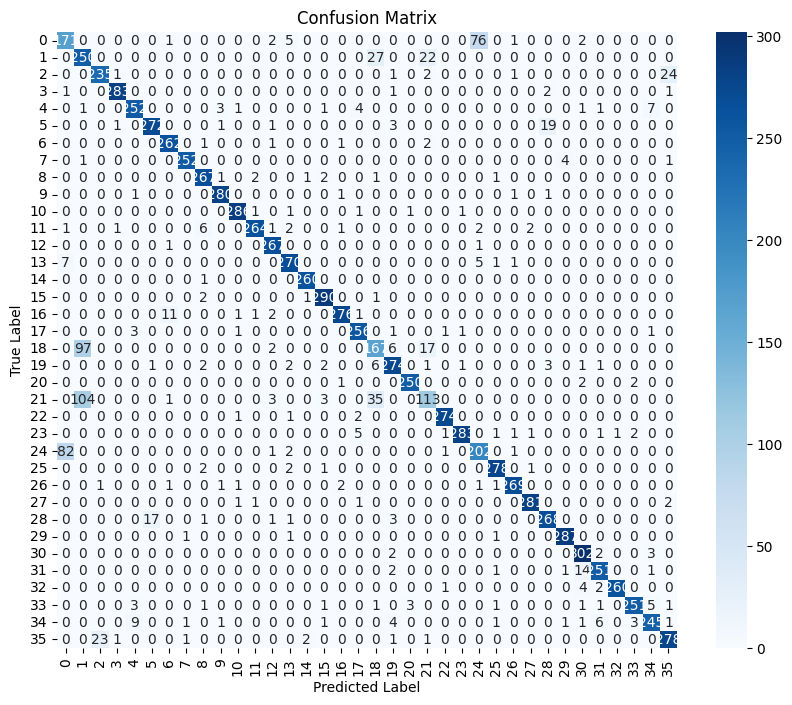

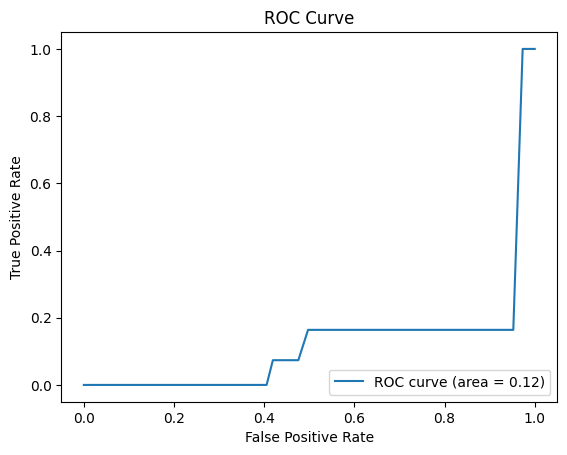

In [14]:
#Plotting Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#Plotting ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_preds, pos_label=1)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

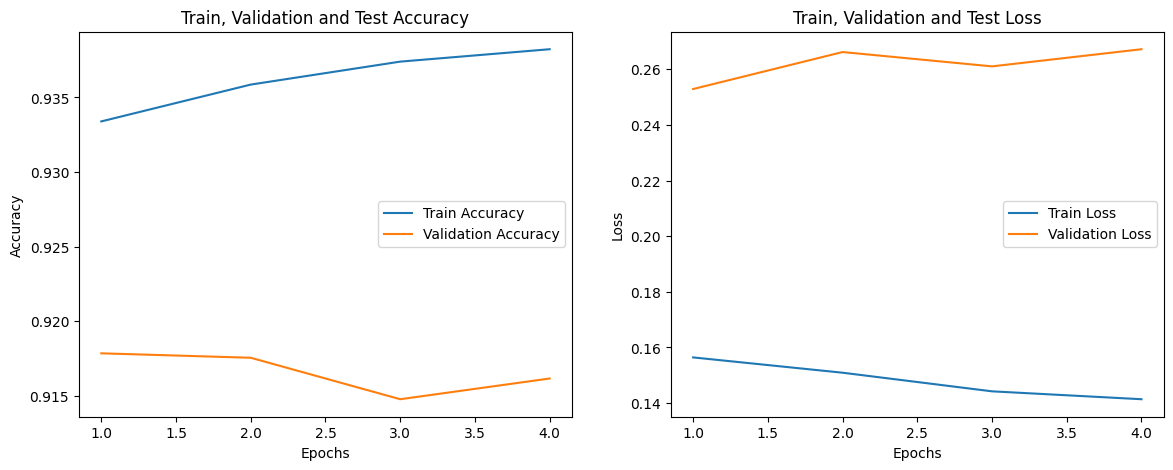

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

# 1. Plotting Accuracy and Loss
def training_metrics_plot(train_accuracies, val_accuracies, test_accuracy, train_losses, val_losses):
    epochs = range(1, len(train_accuracies) + 1)
    plt.figure(figsize=(14, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_accuracies, label='Train Accuracy')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Train, Validation and Test Accuracy')

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Train, Validation and Test Loss')

    plt.show()

# Assuming you collect train and validation accuracies and losses during training
training_metrics_plot(train_accuracies, val_accuracies, test_accuracy, training_losses, validation_losses)


In [17]:
"References:https://www.geeksforgeeks.org/introduction-convolution-neural-network/,https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html,https://pytorch.org/docs/stable/nn.html,https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html, https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc"

'References:https://www.geeksforgeeks.org/introduction-convolution-neural-network/,https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html,https://pytorch.org/docs/stable/nn.html,https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html, https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc'